In [ ]:
# Phase 1 : Statistiques de base du dataset
#1 Nombre d’images par split (train / val / test)
import os

data_directory = "../data/raw/chest_xray"

splits = ["test", "train", "val"]
classes = ["normal", "pneumonia"]

test, train, val = 0,0,0
test_norm, test_pne, train_norm, train_pne, val_norm, val_pne = 0,0,0,0,0,0

for split in splits :
    split_path = os.path.join(data_directory, split)
    if os.path.exists(split_path):
        total = 0
        
        for classe in classes : 
            cls = os.path.join(split_path, classe)
            total += len( [img for img in os.listdir(cls)])
        
        print(f"number of images in {split} : ", total)
        
        if split == "test" :
            test = total
        elif split == "train":
            train = total
        elif split == "val":
            val = total
        else:
            break
    else:
        print(f"{split_path} dosent exists")


number of images in test :  624
number of images in train :  5216
number of images in val :  16


In [4]:
#2 Nombre d’images par classe (normal / pneumonia)
for split in splits :
    split_path = os.path.join(data_directory, split)
    if os.path.exists(split_path):
        
        for classe in classes : 
            cls = os.path.join(split_path, classe)
            total = len( [img for img in os.listdir(cls)])
            print(f"number of images in {split} - {classe}: ", total)

            if split == "test"  and classe == "normal":
                test_norm = total
            elif split == "test"  and classe == "pneumonia":
                test_pne = total
            elif split == "train"  and classe == "normal":
                train_norm = total
            elif split == "train"  and classe == "pneumonia":
                train_pne = total
            elif split == "val"  and classe == "normal":
                val_norm = total
            elif split == "val"  and classe == "pneumonia":
                val_pne = total
            else:
                break
    else:
        print(f"{split_path} dosent exists")

number of images in test - normal:  234
number of images in test - pneumonia:  390
number of images in train - normal:  1341
number of images in train - pneumonia:  3875
number of images in val - normal:  8
number of images in val - pneumonia:  8


In [16]:
# 3 Pourcentage de déséquilibre
print(f"test normal = {(test_norm/test) * 100} %, test pneumonia = {100 - (test_norm/test) * 100 }%")
print(f"train normal = {(train_norm/train) * 100} %, train pneumonia = {100 - (train_norm/train) * 100}%")
print(f"val normal = {(val_norm/val) * 100} %, val pneumonia = {(val_pne/val) * 100}%")

test normal = 37.5 %, test pneumonia = 62.5%
train normal = 25.709355828220858 %, train pneumonia = 74.29064417177915%
val normal = 50.0 %, val pneumonia = 50.0%


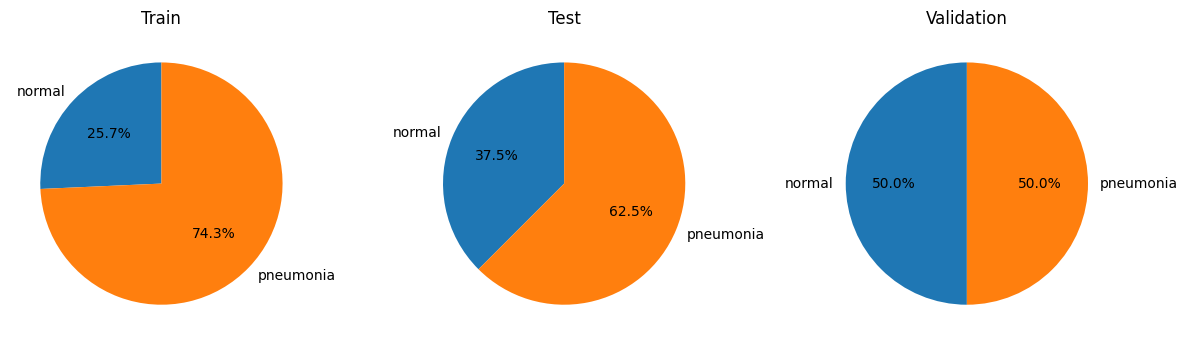

In [ ]:
# Phase 2 : Visualisation de la distribution des classes
# pie chart : 
import matplotlib.pyplot as plt 

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].pie([train_norm, train_pne], labels=classes, autopct='%1.1f%%', startangle=90)
axes[0].set_title("Train")

axes[1].pie([test_norm, test_pne], labels=classes, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Test")

axes[2].pie([val_norm, val_pne], labels=classes, autopct='%1.1f%%', startangle=90)
axes[2].set_title("Validation")

plt.tight_layout()
plt.show()

AttributeError: Rectangle.set() got an unexpected keyword argument 'labels'

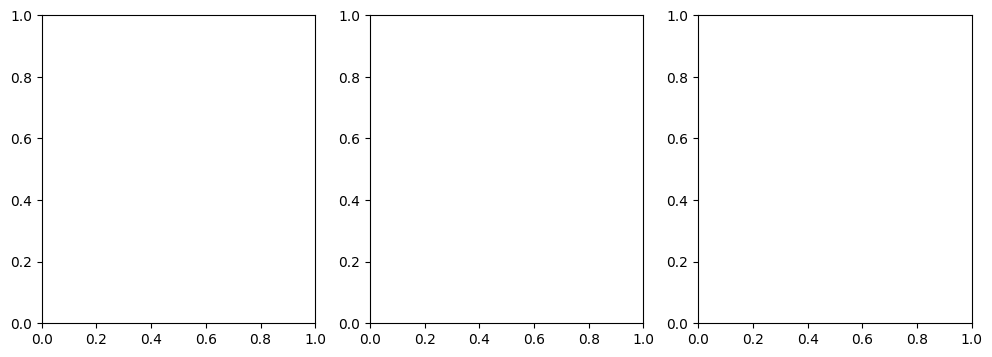

In [ ]:
# Bar plot


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(classes, [train_norm, train_pne])
axes[0].set_title("Train")

axes[1].bar(classes, [test_norm, test_pne])
axes[1].set_title("Test")

axes[2].bar(classes, [val_norm, val_pne])
axes[2].set_title("Validation")

plt.show()

